In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/loan_data.csv')
df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [ ]:
df.shape


df.info()

df.describe()

df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  int64  
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  int64  
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


Exploratory Data Analysis

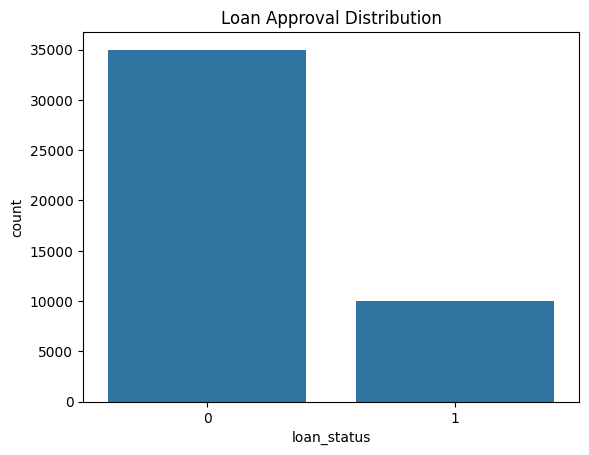

In [ ]:
#Target Distribution
sns.countplot(
    x="loan_status",
    data=df
)

plt.title("Loan Approval Distribution")
plt.show()

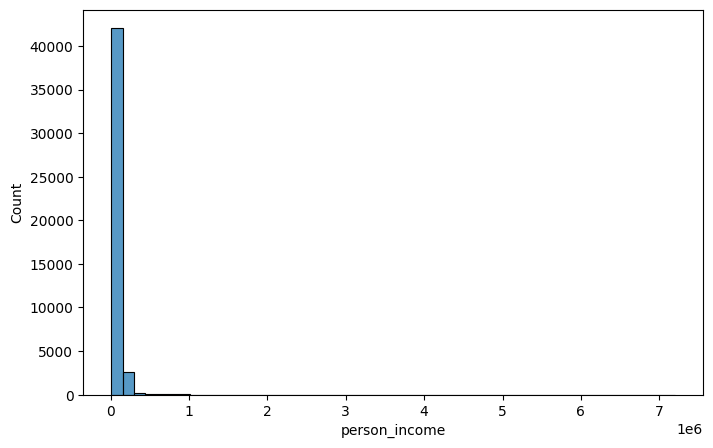

In [ ]:
#Income Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["person_income"],
    bins=50
)

plt.show()

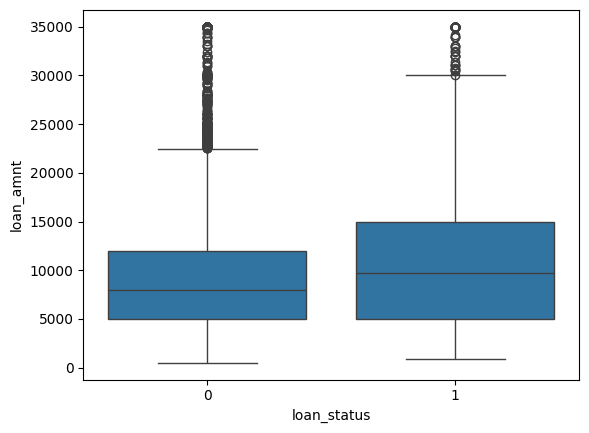

In [ ]:
#Loan Amount Analysis
sns.boxplot(
    x="loan_status",
    y="loan_amnt",
    data=df
)

plt.show()

Handle Missing Values

In [ ]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [ ]:
df.fillna(
    df.median(numeric_only=True),
    inplace=True
)
for col in df.select_dtypes('object'):
    df[col].fillna(
        df[col].mode()[0],
        inplace=True
    )

/tmp/ipykernel_1077/2924147002.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(


Encode Categorical Variables

In [ ]:
encoder = LabelEncoder()

for col in df.select_dtypes("object"):
    df[col] = encoder.fit_transform(df[col])

Split Features and Target

In [ ]:
X = df.drop(
    "loan_status",
    axis=1
)
y = df["loan_status"]


Feature Scaling

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Build ANN Model

In [ ]:
model = Sequential()


model.add(
    Dense(
        128,
        activation="relu",
        input_shape=(X_train.shape[1],)
    )
)


model.add(
    Dropout(0.3)
)


model.add(
    Dense(
        64,
        activation="relu"
    )
)


model.add(
    Dense(
        32,
        activation="relu"
    )
)


model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Train ANN

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8835 - loss: 0.2495 - val_accuracy: 0.8922 - val_loss: 0.2257
Epoch 2/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8988 - loss: 0.2197 - val_accuracy: 0.8994 - val_loss: 0.2167
Epoch 3/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9022 - loss: 0.2130 - val_accuracy: 0.9011 - val_loss: 0.2131
Epoch 4/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9048 - loss: 0.2084 - val_accuracy: 0.9011 - val_loss: 0.2141
Epoch 5/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9075 - loss: 0.2039 - val_accuracy: 0.9029 - val_loss: 0.2094
Epoch 6/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9081 - loss: 0.2007 - val_accuracy: 0.9026 - val_loss: 0.2071
Epoch 7/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9094 - loss: 0.1990 - val_accuracy: 0.9029 - val_loss: 0.2081
Epoch 8/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9111 - loss: 0.1975 - val_accuracy: 0.

Model Evaluation

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:",accuracy)

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9181 - loss: 0.1834
Accuracy: 0.9181110858917236


In [ ]:
y_pred = model.predict(X_test)

y_pred = (y_pred>0.5).astype(int)

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7000
           1       0.87      0.74      0.80      2000

    accuracy                           0.92      9000
   macro avg       0.90      0.85      0.87      9000
weighted avg       0.92      0.92      0.92      9000



Confusion Matrix

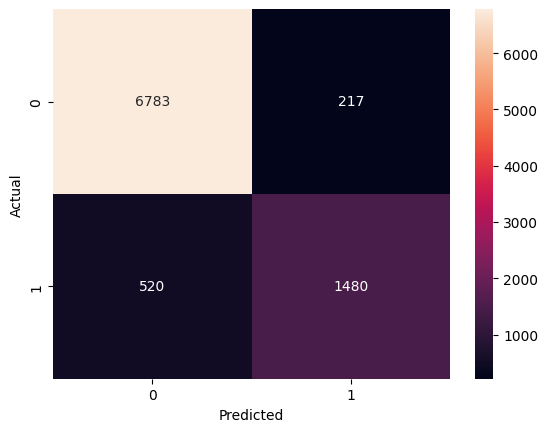

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

ROC-AUC Score

In [ ]:
prob = model.predict(X_test)

roc_auc_score(
    y_test,
    prob
)

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


np.float64(0.9675849285714286)

Save Model

In [ ]:
model.save(
    "loan_ann_model.keras"
)

In [ ]:
import pickle

pickle.dump(
    scaler,
    open("scaler.pkl","wb")
)

Install Streamlit

In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 109.6 MB/s eta 0:00:00


In [ ]:
pip install tensorflow pandas numpy scikit-learn

In [ ]:
import streamlit as st
import numpy as np
import pickle

from tensorflow.keras.models import load_model


# Load trained model
model = load_model("loan_ann_model.keras")


# Load scaler
with open("scaler.pkl","rb") as file:
    scaler = pickle.load(file)


# Page title

st.title("🏦 Loan Approval Prediction")

st.write(
    "Enter applicant details to predict loan approval"
)


# User inputs

age = st.number_input(
    "Age",
    min_value=18,
    max_value=100
)


income = st.number_input(
    "Annual Income"
)


home = st.selectbox(
    "Home Ownership",
    ["Rent","Own","Mortgage"]
)


employment = st.number_input(
    "Employment Length"
)


loan_intent = st.selectbox(
    "Loan Purpose",
    [
        "Personal",
        "Education",
        "Medical",
        "Business"
    ]
)


loan_amount = st.number_input(
    "Loan Amount"
)


interest = st.number_input(
    "Interest Rate"
)


credit_history = st.selectbox(
    "Previous Default",
    [0,1]
)


credit_length = st.number_input(
    "Credit History Length"
)


# Convert inputs

if st.button("Predict Loan Status"):


    input_data = np.array([[
        age,
        income,
        home,
        employment,
        loan_intent,
        loan_amount,
        interest,
        credit_history,
        credit_length
    ]])


    # Scale input

    input_scaled = scaler.transform(input_data)


    # Prediction

    prediction = model.predict(input_scaled)


    probability = prediction[0][0]


    if probability > 0.5:

        st.success(
            f"Loan Approved ✅\nProbability: {probability:.2f}"
        )

    else:

        st.error(
            f"Loan Rejected ❌\nProbability: {probability:.2f}"
        )

2026-07-31 19:03:42.752 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-31 19:03:43.356 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-31 19:03:43.359 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-31 19:03:43.360 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-31 19:03:43.363 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-31 19:03:43.364 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-31 19:03:43.367 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-31 19:03:43.368 Thread 'MainThread': mi

Run Streamlit Application